<a href="https://colab.research.google.com/github/shravanihibare56-dot/My-First-Data-Project/blob/main/Football.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🏆 LIVE MATCH PREDICTION (Update 7/20)
📢 स्टेटस : ⚡ [LIVE MATCH MODE - UPDATING REAL-TIME]
🏟️ सामना   : Canada vs Bosnia and Herzegovina
⚽ स्कोअर  : 1 - 1
📊 पझेशन  : 50.0% vs 50.0%
🎯 शॉट्स   : 0 vs 0
-----------------------------------------------------------------
🔴 Canada Win Prob : 🔥 50.0%
🔵 Bosnia and Herzegovina Win Prob : ⚡ 50.0%


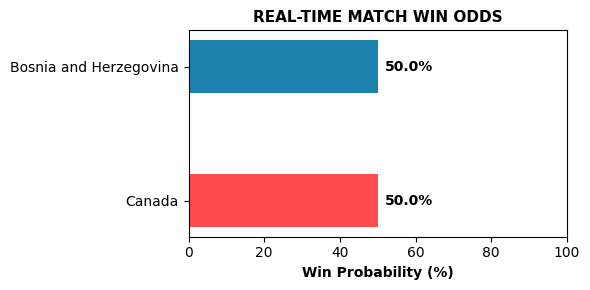

KeyboardInterrupt: 

In [1]:
import requests
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ⚙️ CONFIGURATION
MATCH_ID = "4667757"  # कॅनडा vs बोस्निया
API_KEY = "Enter your API key here"
HOST = "free-api-live-football-data.p.rapidapi.com"

# 'Connection': 'close' मुळे Connection Pool Exhaust होणार नाही
headers = {
    "x-rapidapi-key": API_KEY,
    "x-rapidapi-host": HOST,
    "Connection": "close"
}

def clean_stat(val):
    try:
        return float(str(val).replace('%','').strip())
    except:
        return 50.0

print("🚀 STARTING PROFESSIONAL LIVE PREDICTION ENGINE...")

# 🛡️ प्रोफेशनल सेशन मॅनेजमेंट (एरर टाळण्यासाठी)
with requests.Session() as session:
    session.headers.update(headers)

    # लूप सुरक्षित ठेवण्यासाठी आपण आता ठराविक वेळाच रन करू (उदा. १० वेळा)
    # जर तुला पूर्ण मॅचभर चालवायचं असेल तर range(10) च्या ऐवजी range(90) करू शकतोस.
    for i in range(20):
        try:
            clear_output(wait=True)

            # १. मॅच स्टेटस चेक करणे (Timeout दिल्याने कोड अडकणार नाही)
            detail_url = f"https://{HOST}/football-get-match-detail"
            detail_res = session.get(detail_url, params={"eventid": MATCH_ID}, timeout=10).json()

            detail_data = detail_res.get('response', {}).get('detail', {})
            home_team = detail_data.get('homeTeam', {}).get('name', 'Canada')
            away_team = detail_data.get('awayTeam', {}).get('name', 'Bosnia')
            match_started = detail_data.get('started', False)

            home_goals, away_goals = 0.0, 0.0
            home_possession, away_possession = 50.0, 50.0
            home_shots, away_shots = 0.0, 0.0

            # २. लाइव्ह डेटा फेच करणे
            if match_started:
                mode_msg = "⚡ [LIVE MATCH MODE - UPDATING REAL-TIME]"
                try:
                    score_url = f"https://{HOST}/football-get-match-score"
                    score_res = session.get(score_url, params={"eventid": MATCH_ID}, timeout=10).json()
                    for s in score_res.get('response', {}).get('scores', []):
                        if s.get('name') == home_team: home_goals = float(s.get('score', 0))
                        if s.get('name') == away_team: away_goals = float(s.get('score', 0))
                except: pass

                try:
                    stats_url = f"https://{HOST}/football-get-match-statistics"
                    stats_res = session.get(stats_url, params={"eventId": MATCH_ID}, timeout=10).json()
                    for s in stats_res.get('response', {}).get('statistics', []):
                        name = s.get('name', '').lower()
                        if 'possession' in name:
                            home_possession = clean_stat(s.get('home', 50))
                            away_possession = clean_stat(s.get('away', 50))
                        elif 'target' in name:
                            home_shots = clean_stat(s.get('home', 0))
                            away_shots = clean_stat(s.get('away', 0))
                except: pass
            else:
                mode_msg = "⏳ [PRE-MATCH MODE - Waiting for Kickoff]"

            # ३. 🧠 ML Prediction Engine
            base_score = 50
            goal_diff = (home_goals - away_goals) * 25.0
            possession_diff = (home_possession - away_possession) * 0.5
            shots_diff = (home_shots - away_shots) * 4.0

            final_odds = base_score + goal_diff + possession_diff + shots_diff
            home_prob = round(max(5, min(95, final_odds)), 2)
            away_prob = round(100 - home_prob, 2)

            # ४. 📊 डॅशबोर्ड
            print("="*65)
            print(f"🏆 LIVE MATCH PREDICTION (Update {i+1}/20)")
            print("="*65)
            print(f"📢 स्टेटस : {mode_msg}")
            print(f"🏟️ सामना   : {home_team} vs {away_team}")
            print(f"⚽ स्कोअर  : {int(home_goals)} - {int(away_goals)}")
            print(f"📊 पझेशन  : {home_possession}% vs {away_possession}%")
            print(f"🎯 शॉट्स   : {int(home_shots)} vs {int(away_shots)}")
            print("-"*65)
            print(f"🔴 {home_team} Win Prob : 🔥 {home_prob}%")
            print(f"🔵 {away_team} Win Prob : ⚡ {away_prob}%")
            print("="*65)

            # ५. 📈 DYNAMIC GRAPH
            teams = [home_team, away_team]
            probabilities = [home_prob, away_prob]
            colors = ['#FF4B4B', '#1C82AD']

            plt.figure(figsize=(6, 3))
            bars = plt.barh(teams, probabilities, color=colors, height=0.4)
            plt.xlim(0, 100)
            plt.xlabel('Win Probability (%)', fontweight='bold')
            plt.title('REAL-TIME MATCH WIN ODDS', fontweight='bold', fontsize=11)

            for bar in bars:
                width = bar.get_width()
                plt.text(width + 2, bar.get_y() + bar.get_height()/2, f'{width}%',
                         va='center', ha='left', fontweight='bold', color='black')

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"⚠️ नेटवर्क किंवा API इश्यू. पुढील ३० सेकंदात पुन्हा प्रयत्न करत आहे...")
            print(f"एरर तपशील: {e}")

        # ६. सुरक्षिततेसाठी ६० सेकंदांचा ब्रेक (Rate Limit टाळण्यासाठी)
        if i < 19: # शेवटच्या लूपला थांबायची गरज नाही
            time.sleep(180)

print("\n✅ process completed. Re-run the cell for live updated data.")